# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Mengatur gaya visualisasi agar rapi
sns.set_theme(style="whitegrid")
print("Library berhasil di-import!")

Library berhasil di-import!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
# Memuat data dari session storage Colab
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Menampilkan informasi ringkas dataset
print(f"Jumlah baris: {df.shape[0]}, Jumlah kolom: {df.shape[1]}\n")
print("5 Baris Pertama Data:")
display(df.head())

print("\nInformasi Tipe Data Fitur:")
df.info()

Jumlah baris: 7043, Jumlah kolom: 21

5 Baris Pertama Data:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Informasi Tipe Data Fitur:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilli

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

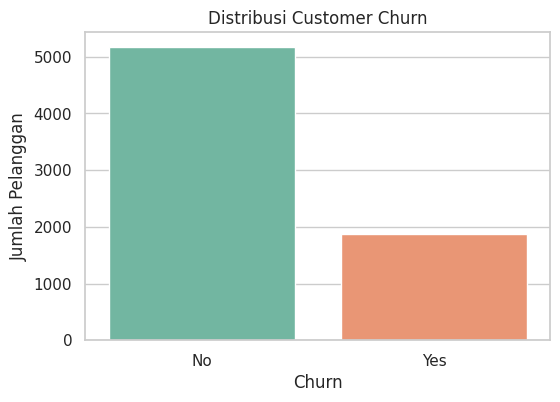

Persentase Tetap Berlangganan (No): 73.46%
Persentase Berhenti Berlangganan (Yes): 26.54%



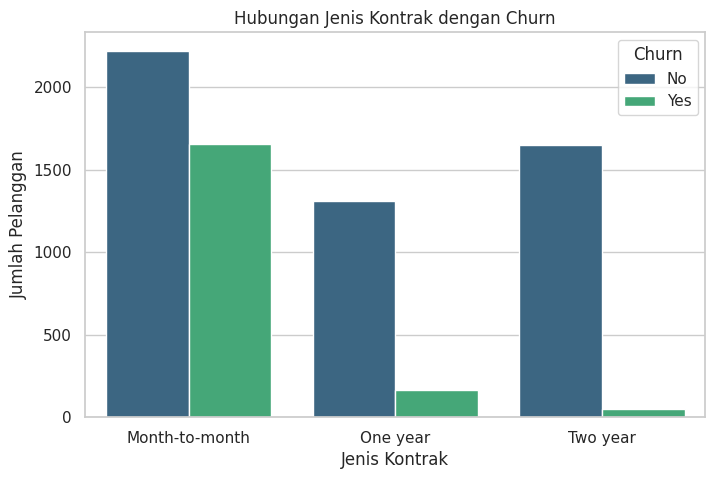

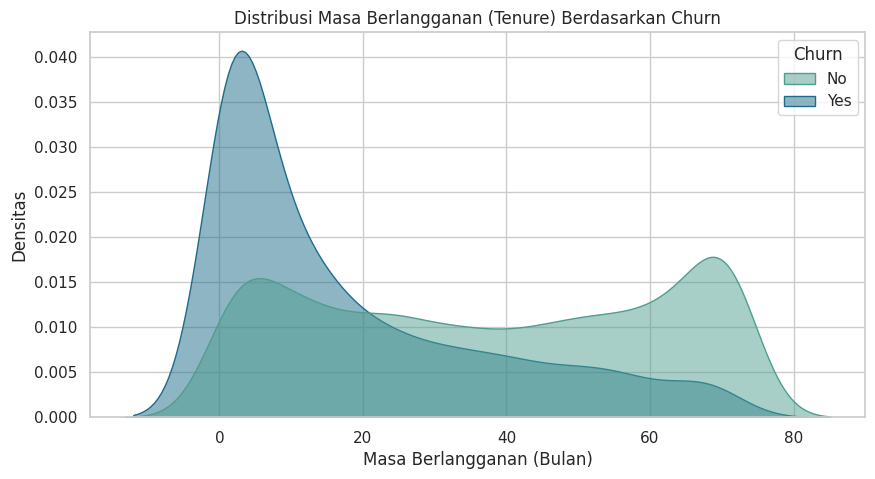

In [3]:
# 1. Memeriksa Distribusi Target Variabel (Churn)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', hue='Churn', palette='Set2', legend=False)
plt.title('Distribusi Customer Churn')
plt.xlabel('Churn')
plt.ylabel('Jumlah Pelanggan')
plt.show()

# Menampilkan persentase churn
churn_pct = df['Churn'].value_counts(normalize=True) * 100
print(f"Persentase Tetap Berlangganan (No): {churn_pct['No']:.2f}%")
print(f"Persentase Berhenti Berlangganan (Yes): {churn_pct['Yes']:.2f}%\n")

# 2. Visualisasi Hubungan Antara Jenis Kontrak dan Churn
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Contract', hue='Churn', palette='viridis')
plt.title('Hubungan Jenis Kontrak dengan Churn')
plt.xlabel('Jenis Kontrak')
plt.ylabel('Jumlah Pelanggan')
plt.legend(title='Churn')
plt.show()

# 3. Visualisasi Distribusi Masa Berlangganan (Tenure) berdasarkan Churn
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, common_norm=False, palette='crest', alpha=0.5)
plt.title('Distribusi Masa Berlangganan (Tenure) Berdasarkan Churn')
plt.xlabel('Masa Berlangganan (Bulan)')
plt.ylabel('Densitas')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [4]:
# 1. Menangani missing value tersembunyi (spasi kosong) pada TotalCharges
print("Jumlah missing value awal di TotalCharges sebelum dibersihkan:")
print((df['TotalCharges'].str.strip() == '').sum())

# PERBAIKAN: Format penulisan pd.to_numeric yang benar
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Isi NaN dengan nilai median (karena data TotalCharges biasanya memiliki skewness)
total_charges_median = df['TotalCharges'].median()
df['TotalCharges'].fillna(total_charges_median, inplace=True)
print(f"Missing value setelah di-impute dengan median ({total_charges_median}): {df['TotalCharges'].isnull().sum()}\n")

# 2. Drop fitur yang tidak relevan untuk pemodelan
df_clean = df.drop(columns=['customerID'])

# 3. Encoding Target Variabel (Churn) & Fitur Kategorikal lainnya
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

# Identifikasi fitur kategorikal untuk One-Hot Encoding
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
print(f"Fitur kategorikal yang akan di-encode: {categorical_cols}\n")

# Menerapkan One-Hot Encoding
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

# 4. Memisahkan Fitur (X) dan Target (y)
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# 5. Membagi data menjadi Train dan Test Set (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Proses Preprocessing Selesai!")
print(f"Dimensi X_train: {X_train.shape}, Dimensi X_test: {X_test.shape}")

Jumlah missing value awal di TotalCharges sebelum dibersihkan:
11
Missing value setelah di-impute dengan median (1397.475): 0

Fitur kategorikal yang akan di-encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Proses Preprocessing Selesai!
Dimensi X_train: (5634, 30), Dimensi X_test: (1409, 30)


/tmp/ipykernel_4964/3151936632.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(total_charges_median, inplace=True)


# **6. Evaluasi Model**

Mulai melatih Baseline Model (Random Forest)...
Model berhasil dilatih!

Akurasi Baseline Model: 78.64%

Classification Report:
              precision    recall  f1-score   support

  Tetap (No)       0.83      0.89      0.86      1035
 Churn (Yes)       0.62      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.77      0.79      0.78      1409



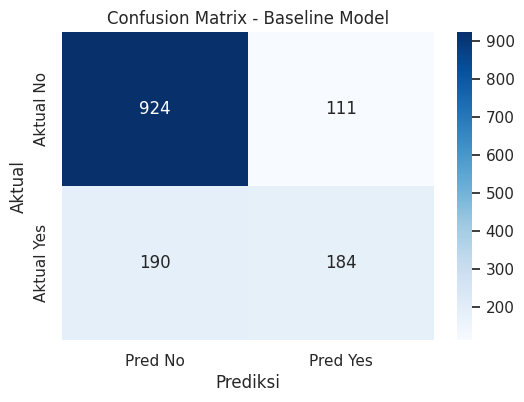

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

print("Mulai melatih Baseline Model (Random Forest)...")

# 1. Inisialisasi Baseline Model
baseline_model = RandomForestClassifier(random_state=42)

# 2. Pelatihan Model menggunakan data Train
baseline_model.fit(X_train, y_train)
print("Model berhasil dilatih!")

# 3. Prediksi menggunakan data Test
y_pred = baseline_model.predict(X_test)

# 4. Evaluasi Kinerja Model
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAkurasi Baseline Model: {accuracy * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Tetap (No)', 'Churn (Yes)']))

# 5. Visualisasi Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred No', 'Pred Yes'], yticklabels=['Aktual No', 'Aktual Yes'])
plt.title('Confusion Matrix - Baseline Model')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.show()